# Chapter 0: N-gram Markov Models

Understanding modern generative AI like LLMs today is important since they are the basis for many applications and tools we use today. I remember when I started my Computer Science degree in 2017, and the most hyped AI in the market was IBM Watson Assistant. It led all banks in Brazil to develop a personal ChatBot assistant based on it, and also on Telegram. It was good at language understanding, but it wasn't able to generate text. It was only able to recognize a topic registered through Intents, and for each topic, the developer needs to set a predefined answer.

<figure>
    <img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*iXWvm5p3cLqu4ghM-3ImHw.png" alt="Watson assistant." width="800" height="400">
    <figcaption>Image by Chris Desmarais.</figcaption>
</figure>

Creating one answer for each possible topic was a hard task, and those assistants were not scalable. In this chapter, we will see how we can generate text and learn the fundamental concepts behind LLMs and modern generative AI.

## Learning to write

To generate text, we first need to learn how to read. For this, let's start with a text about computers from Wikipedia. Let's fetch the Wikipedia page and extract the text from it.

In [1]:
import requests

url = 'https://en.wikipedia.org/wiki/Computer'

# Wikipedia blocks requests that do not have a user-agent header, so we need to set it to something like a browser.
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})

# Let's see what it looks like
print(response.text[:500])

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25easte


Ok, we have the HTML of the page, and we need to extract the text from it. Extracting information from web pages is called web scraping and is a good source of data for training language models. We can use the BeautifulSoup library to parse it.

In [2]:
from bs4 import BeautifulSoup

# Build parser
doc = BeautifulSoup(response.text, 'html.parser')

# The content is inside a div with id bodyContent, so we can extract from it.
text = '\n'.join([x.text for x in doc.find('div', {'id': 'bodyContent'})])

print(text[:200])







From Wikipedia, the free encyclopedia







Programmable machine that processes data
For the consumer oriented device which is also usually just called a computer, see Personal computer.
For ot


Our text has a lot of spaces. Let's clean it up by replacing multiple newlines with a single one.


In [3]:
import re

cleaned_text = re.sub(r'\n+', '\n', text)

print('Characters:', len(cleaned_text))
print('Example:\n', cleaned_text[:500])

Characters: 105547
Example:
 
From Wikipedia, the free encyclopedia
Programmable machine that processes data
For the consumer oriented device which is also usually just called a computer, see Personal computer.
For other uses, see Computer (disambiguation).
Computers and computing devices from different eras—left to right, top to bottom:
Early vacuum-tube computer (ENIAC)Mainframe computer (IBM System/360)Smartphone (LYF Water 2)Desktop computer (IBM ThinkCentre S50 with monitor)Video game console (Nintendo GameCube)Superco


---

Now that we have our cleaned text, we can start learning how to read it. The simplest way to do this is by learning to predict the next word in a sentence. For example, in the sentence:

*Computer is a ______*

What word is more likely to fill the blank? There are a lot of options like "machine", "device", etc. However, it is very unlikely that the word "banana" will fill the blank. To learn what words are more likely to appear after a sentence, we can count the number of times one word appears after this sentence.

The problem is that we have a lot of possible sentences with words that can come next, and we won't be able to store all that information.

The solution to this problem is considering the Markov assumption that to estimate the probability of the next word, we need to consider only n previous words. Now we can solve our problem.

## Markov Models

The first step is splitting our text into words. This is a complex problem by itself, but for simplicity, we can predict the next character or the next n characters instead of the next word. Those smaller text pieces are called tokens, and the process of splitting the text into tokens is called tokenization.

It is very easy to split a text into characters because the string is already a sequence of characters.

In [4]:
print(list(cleaned_text[:20]))

['\n', 'F', 'r', 'o', 'm', ' ', 'W', 'i', 'k', 'i', 'p', 'e', 'd', 'i', 'a', ',', ' ', 't', 'h', 'e']


However, to build better models, we can split the text into n-grams, which are sequences of n characters.

In [5]:
import itertools

# We can use the itertools.batched function to split the text into n-grams.
n_grams = 2
tokens = [''.join(x) for x in itertools.batched(cleaned_text, n_grams)]
print(tokens[:10])

['\nF', 'ro', 'm ', 'Wi', 'ki', 'pe', 'di', 'a,', ' t', 'he']


We can also use a sliding window to get more combinations of characters from our text, leading to a better model.

In [6]:
tokens = []
for i in range(len(cleaned_text) - n_grams + 1):
    tokens.append(cleaned_text[i:i+n_grams])

print(tokens[:10])

['\nF', 'Fr', 'ro', 'om', 'm ', ' W', 'Wi', 'ik', 'ki', 'ip']


Pack both approaches in a function to make it easier to use.

In [7]:
def tokenize(text, n_grams, sliding=True):
    if not sliding:
        return [''.join(x) for x in itertools.batched(text, n_grams)]

    tokens = []
    for i in range(len(text) - n_grams + 1):
        tokens.append(text[i:i+n_grams])
    return tokens

Now, to compute the probabilities, we need to get the unique tokens in our text and assign an index to each one of them so we can easily work with them.

In [8]:
# building our vocabulary and converting to a list so we can iterate it in the same order
vocab = list(set(tokens))
print('Vocabulary sample:', vocab[:10])

# creating the word indexes
word_index = {c: i for i, c in enumerate(vocab)}
index_word = {i: c for i, c in enumerate(vocab)}

print('Word index sample:', list(word_index.items())[:10])

# put everything into a function
def build_vocab(tokens):
    vocab = list(set(tokens))
    wi = {c: i for i, c in enumerate(vocab)}
    iw = {i: c for i, c in enumerate(vocab)}
    return wi, iw

Vocabulary sample: ['S1', 'nī', '8-', 'yo', 'x,', 'g-', '88', 'ru', 'ot', 'og']
Word index sample: [('S1', 0), ('nī', 1), ('8-', 2), ('yo', 3), ('x,', 4), ('g-', 5), ('88', 6), ('ru', 7), ('ot', 8), ('og', 9)]


Now we can build our Markov model by counting the number of times each token appears after another token.

Let's do a small example to understand how it works.

In [9]:
example_text = 'A computer is a machine.'

# let's consider only the next character for simplicity
n_grams = 1

# tokenize the sequence
tokens = tokenize(example_text, n_grams=n_grams)
print('tokens', tokens)

# build the vocabulary
wi, iw = build_vocab(tokens)
print('word index', wi)

tokens ['A', ' ', 'c', 'o', 'm', 'p', 'u', 't', 'e', 'r', ' ', 'i', 's', ' ', 'a', ' ', 'm', 'a', 'c', 'h', 'i', 'n', 'e', '.']
word index {' ': 0, '.': 1, 'c': 2, 'm': 3, 'o': 4, 'e': 5, 'i': 6, 'a': 7, 'r': 8, 'A': 9, 'n': 10, 'u': 11, 's': 12, 't': 13, 'h': 14, 'p': 15}


We can use tables to store our statistics. The rows represent the current token, and the columns represent the next token.

|   | A |  | c | o |
|---|---| --- | --- | --- |
| A | 0 | 0 | 0 | 0 |
|   | 0 | 0 | 0 | 0 |
| c | 0 | 0 | 0 | 0 |
| o | 0 | 0 | 0 | 0 |

Starting with the first token "A", we see that the next token is " ", so we add 1 to the cell in row A and column " ".

|   | A |   | c | o |
|---|---|---| --- | --- |
| A | 0 | 1 | 0 | 0 |
|   | 0 | 0 | 0 | 0 |
| c | 0 | 0 | 0 | 0 |
| o | 0 | 0 | 0 | 0 |

Now we move the current token to the next token of A that is " ", and do the same. In this case, the next token is "c", so we add 1 to the cell (" ", "c").

|   | A |   | c | o |
|---|---|---|---| --- |
| A | 0 | 1 | 0 | 0 |
|   | 0 | 0 | 1 | 0 |
| c | 0 | 0 | 0 | 0 |
| o | 0 | 0 | 0 | 0 |

Now, let's do this with the whole text. Exercise for the reader: complete the code below:

In [ ]:
# starting with an empty matrix of counts
matrix = [[0 for _ in range(len(wi))] for _ in range(len(wi))]

# index of current token
current_token_index = wi[tokens[0]]

for next_token in tokens[1:]:
    # index of the next token
    next_token_index =

    # row of the current token, where each column is the count of all possible next tokens
    row =

    # increase the count


    # now the current token is the next
    current_token_index = next_token_index

In [ ]:
# Now let's test if it works by plotting the counts for the token "c"

import matplotlib.pyplot as plt

# index of the token "c"
c_index = wi['c']

# column of the token "c"
column_chars = [iw[i] for i in range(len(wi))]

# values of the column of the token "c"
column_values = [matrix[c_index][i] for i in range(len(wi))]

# plotting
plt.bar(column_chars, column_values)
plt.show()

If it works, we can see that in our example, the next tokens after "c" are "o" in "computer" and "h" in "machine". This is a count of 1 in the "h" column and 1 in the "o" column.

To have our probability distribution, we just need to normalize the values so that they sum to 1. To do this, we need to divide each value by the total count of next tokens for the current token.

In [ ]:
# normalizing the matrix

for i in range(len(matrix)):
    row = matrix[i]
    total = sum(row)
    if total > 0:
        matrix[i] = [x / total for x in row]

One optimization we can do is to use a dictionary to store the counts instead of a matrix, since most of the values will be zero, and we can save a lot of memory by not storing them.

Also, since we will train using the sliding window approach, we need to skip the intersections of the n-grams, so we need to consider only the tokens that are n-grams apart.

In [10]:
# putting everything together in a function
def compute_markov(tokens, wi, n_grams, normalize=True):
    mat = {}

    for i in range(len(tokens) - n_grams):
        current_token = tokens[i]
        # skipping the tokens that are in the intersection of the n-grams
        next_token = tokens[i + n_grams]

        # adding the current token to the matrix if it is not there
        if wi[current_token] not in mat:
            mat[wi[current_token]] = {}

        # adding the next token in the current token row if it is not there
        if wi[next_token] not in mat[wi[current_token]]:
            mat[wi[current_token]][wi[next_token]] = 0

        # updating the count of the next token in the current token row
        mat[wi[current_token]][wi[next_token]] += 1

    if not normalize:
        return mat

    # normalizing the matrix
    for k, v in mat.items():
        total = sum(v.values())
        if total == 0:
            continue
        for next_token in v:
            mat[k][next_token] /= total

    return mat

Let's compute the Markov model from the Wikipedia text.

In [11]:
# Let's start with a simple model that considers only the next character, so n_grams = 1
n_grams = 1

# tokenize the text
tokens = tokenize(cleaned_text, n_grams)

# build the vocabulary and get the word indexes
wi, iw = build_vocab(tokens)

# Let's see some statistics about our text and the model
print('N-grams:', n_grams)
print('Vocab:', len(wi))
print('Tokens:', len(tokens))

# compute the Markov model
markov = compute_markov(tokens, wi, n_grams)

N-grams: 1
Vocab: 108
Tokens: 105547


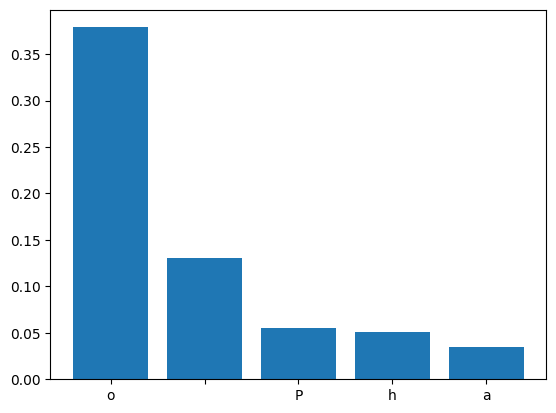

In [14]:
# Let's see the top 5 most probable next tokens for the token "C"

# index of the token "C"
c_index = wi['C']

# probabilities of the next tokens given the current token "C"
probs = markov[c_index]

tk = []
pb = []

# sorting the probabilities in descending order and getting the top 5 tokens and their probabilities
for t, p in sorted(probs.items(), key=lambda item: item[1], reverse=True):
    tk.append(iw[t])
    pb.append(p)

# plotting
top_k = 5
plt.bar(tk[:top_k], pb[:top_k])
plt.show()

We can see that the most probable next token after "C" is "o", which makes sense since the word "Computer" is very common in the text.

# Now we can write

Now that we have our Markov model, we can use it to generate text.

To do it, we need to start with a token and get the most probable next token given the current token.

In [15]:
# Let's start with the token "C" and generate text from it
generated_text = 'C'

current_token_index = wi[generated_text]

# getting the next most probable token
probs = markov[current_token_index]

# token with the highest probability
most_probable = max(probs, key=probs.get)

# the most probable should be "o"
print('Most probable token:', iw[most_probable])

# now we add this token back to the generated text
generated_text += iw[most_probable]
print('Generated text:', generated_text)

# Now we just repeat this process as long as we want.
max_tokens = 20 # 20 new tokens

for _ in range(max_tokens):
    current_token_index = wi[generated_text[-1]]
    probs = markov[current_token_index]
    most_probable = max(probs, key=probs.get)
    generated_text += iw[most_probable]

print('Final generated text:', generated_text)

Most probable token: o
Generated text: Co
Final generated text: Con te te te te te te 


We generated some text, but the model gets stuck in a loop. The most probable next token from "n" is " " and following the chain "n" -> " " -> "t" -> "e" -> " " and we come back to the start. This is an interesting example since Markov models can be seen as a weighted graph where the nodes are the tokens and the edges are the probabilities of going from one token to another. In this case, we have a loop in the graph that makes the model get stuck in it:

[![](https://mermaid.ink/img/pako:eNpNjrFuwzAMRH_FuNkx7Eg2Uw1dmk_IVGgRIjYOWkmGIgNNDf97ZaUtyon3jkdywTlYhsIlmmmsTkftq1y-2u2eq9tkzvwApS0wPUAq4sfl_-MbQp0XXi1UijPXcByd2SSWzdVIIzvWULm1Jr5raL_mzGT8awjuNxbDfBmh3szHLat5sibx8Wryq-6PRvaW40uYfYLqZFeWQC34hBKya8RA1BLth6Hvhaxxh5KHRgqS1LeS9i09ibXGVznbNgfq129oQVDb?type=png)](https://mermaid.live/edit#pako:eNpNjrFuwzAMRH_FuNkx7Eg2Uw1dmk_IVGgRIjYOWkmGIgNNDf97ZaUtyon3jkdywTlYhsIlmmmsTkftq1y-2u2eq9tkzvwApS0wPUAq4sfl_-MbQp0XXi1UijPXcByd2SSWzdVIIzvWULm1Jr5raL_mzGT8awjuNxbDfBmh3szHLat5sibx8Wryq-6PRvaW40uYfYLqZFeWQC34hBKya8RA1BLth6Hvhaxxh5KHRgqS1LeS9i09ibXGVznbNgfq129oQVDb)

One way of solving this problem is to sample the next token from the probability distribution of the next tokens. This way, we can get out of loops and generate more diverse text.


In [16]:
import random

max_tokens = 40

generated_text = 'C'

current_token_index = wi[generated_text]

for _ in range(max_tokens):
    current_token_index = wi[generated_text[-1]]
    probs = markov[current_token_index]
    # Let's include the probabilities of all tokens in the vocabulary
    full_probs = [probs[x] if x in probs else 0 for x in range(len(iw))]
    # now we can use random.choices to sample the next token from the probability distribution
    sampled_token = random.choices(range(len(iw)), weights=full_probs, k=1)[0]

    generated_text += iw[sampled_token]

# now we have the final text, and each time we run this code, we will get a different text since we are using sampling generation
print('Final generated text:', generated_text)

Final generated text: CRad Juionaytyse maurantharints Opis ast 


In [17]:
def generate(markov, s, n_grams, wi, iw, max_tokens=100):
    # cut the start if it is not a multiple of n_grams
    ns = s
    if len(ns) % n_grams != 0:
        ns = ns[(len(ns) % n_grams):]

    tokens = tokenize(ns, n_grams, sliding=False)
    last_token = wi[tokens[-1]]
    for _ in range(max_tokens):
        probs = markov[last_token]
        full_probs = [probs[x] if x in probs else 0 for x in range(len(iw))]
        sampled_token = random.choices(range(len(iw)), weights=full_probs, k=1)[0]
        last_token = sampled_token
        s += iw[sampled_token]
    return s

Now let's test it

In [18]:
n_grams = 1
tokens = tokenize(cleaned_text, n_grams)
wi, iw = build_vocab(tokens)
markov = compute_markov(tokens, wi, n_grams)

# Let's start with the sentence "Computer" and generate from it
s = 'Computer'

generated_text = generate(markov, s, n_grams, wi, iw, max_tokens=200)
print(generated_text)

Computer mec frnd Tut KDanca
PCurte sileve tedwit nd Aray monataterthe, an ee d omullere, f w. ime
Re to mar".23.
S. itrung wal tran (wicualmag ae ot, Ner BEnerorowercas d anoucrondaronucet ragathany 2]
^ uan


---

We generated text, but it is not very good. It doesn't make sense and is hard to recognize any word in it. However, we can see that it appears to be modeling the word sizes since it has a lot of spaces, and some punctuation appears to be correct as it puts a space after a comma and a dot, and starts with an uppercase letter after a dot.

Let's increase the n-grams and compare the results.

In [19]:
s = 'Computers'

n_grams = [1, 2, 4]
texts = []

for n in n_grams:
    tokens = tokenize(cleaned_text, n)
    wi, iw = build_vocab(tokens)
    markov = compute_markov(tokens, wi, n)
    generated_text = generate(markov, s, n, wi, iw, max_tokens=100)
    texts.append(generated_text)


for n, text in zip(n_grams, texts):
    print(f'N-grams: {n}')
    print(text)
    print('------')

N-grams: 1
Computersenuluece IVas onthepere C Hed renduroph tos 120. upl: che butiphed g tit tesiconutoariofegr orsin ls
------
N-grams: 2
Computers. ISSN 0-3-5962.
^ a cal and reptect 50 [ru]
Systers of comput computechip bing constriento dows. Moor any, thatichoused integis muctionic (3)
Opt as of ficalsoftwas inalcuital}}
, fie whip. 165] This
------
N-grams: 4
Computers on 7 August 2017. Archived from the same was 12 mm2, controller/Package.
A key on transistoire L. (2016). Archived 17 May 2008.
^ Knight, Jo (10 October 2016. Retrieved 13 August 2010.
^ Lojek, Bo (2007). "Frosch, C. J.; Derick P. Wolf, Stephen (1998). Computer internations were needed. As problem as a tide-predicting hardware accounter Richard Mark I, great utility of Man-month: Essays of specia
------


As we can see, as we increase the n-grams, the generated text gets better. With n-grams = 4, we can recognize some words, and the text is more coherent. This is because with larger n-grams, we are modeling more structure from the text. Let's see the impact of n on the number of tokens and the vocabulary size.

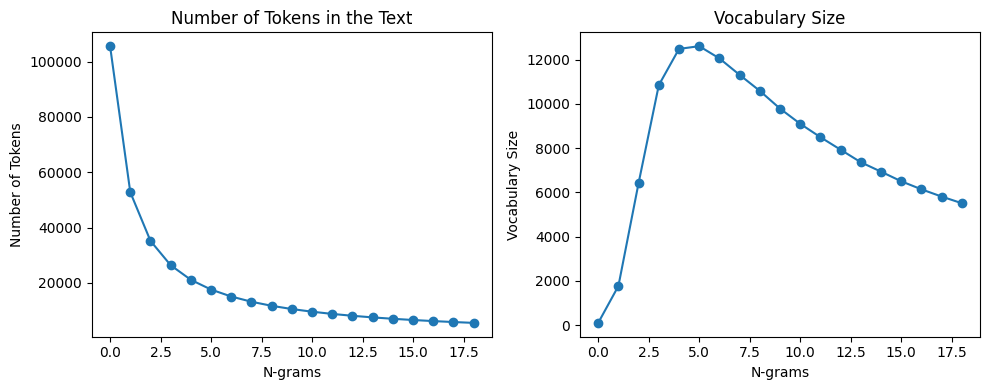

In [20]:
n_tokens = []
n_vocab = []

for i in range(1, 20):
    tokens = tokenize(cleaned_text, i, sliding=False)
    wi, iw = build_vocab(tokens)
    n_tokens.append(len(tokens))
    n_vocab.append(len(wi))


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(n_tokens, marker='o')
ax[0].set_title('Number of Tokens in the Text')
ax[0].set_xlabel('N-grams')
ax[0].set_ylabel('Number of Tokens')

ax[1].plot(n_vocab, marker='o')
ax[1].set_title('Vocabulary Size')
ax[1].set_xlabel('N-grams')
ax[1].set_ylabel('Vocabulary Size')
plt.tight_layout()
plt.show()

The number of tokens in the text reduces as n-grams increase. This is because we are grouping more characters and reducing the number of tokens in the text.

Looking at the vocabulary size, we can see that it starts small and increases as n-grams increase, reaching a peak, and then starts to decrease. Why does this happen?

At n-gram = 1, we have the alphabet and some special characters that are a small number. As n-grams increase, we have more combinations of characters, which also increases the vocabulary size. But why does it start decreasing after a certain point? Imagine $n=length$ of the text, then we have only one token, which is the whole text, so the vocabulary size is 1. Reducing $n$ breaks the text into smaller pieces that increase the vocab size. With that example, we can see that after the peak, the vocabulary starts grouping some unique tokens while reducing the vocab size.

This shows a trade-off between the vocabulary size and generality. While larger n-grams can reduce the number of tokens in the text, leading to compressed and efficient representation, it can also lead to overfitting, as some combinations of tokens appearing in other texts that are not present in the training data may be assigned zero probability (the OOV problem). On the other hand, smaller n-grams can capture more general patterns. Having the alphabet as vocabulary, you can write any text, but that puts more pressure on the model to learn the structure of the language and the dependencies between characters, as we see in the examples with different $n$.



Let's see another example. Let's generate a small text sample.

In [21]:
s = 'Computers'
n_grams = 4
tokens = tokenize(cleaned_text, n_grams)
wi, iw = build_vocab(tokens)
markov = compute_markov(tokens, wi, n_grams)
generated_text = generate(markov, s, n_grams, wi, iw, max_tokens=100)
print(generated_text)

Computers
List of process memory of computer exchange informal analyzers.
^ High level language sources (es)CS1 French-language, Lovelace 100 locations or exchanges provision of John Sarace; Strohmaier, Erich; Simple specialized by Ferranti Mark II (1953)
BESK (1957)
MUSASINO-1 (1957)
TRASK (1964.
^ Young, Ian (2017Articles: Computers contained to the original on 4 February 2026Wikivers. Multiprocessors. W


Now, let's try to find this generated text in the original text.

In [22]:
print(cleaned_text.find(generated_text))

-1


Questions for the reader:

1. If the generated text is not found in the original text, is the model generating new text or just copying from the original text?
2. Are those models just databases?
3. The random sampling method gives the model "creativity"?

# Sampling methods

Let's see the probability distribution of the token "Comp" in the model with n-grams = 4.

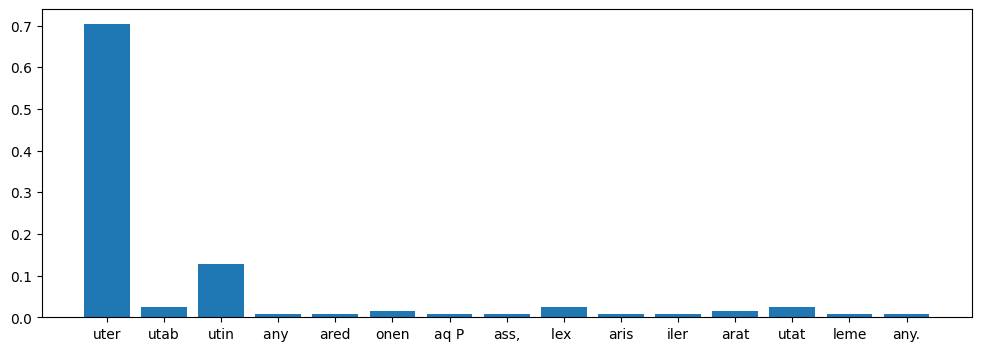

In [23]:
n_grams = 4

tokens = tokenize(cleaned_text, n_grams)
wi, iw = build_vocab(tokens)
markov = compute_markov(tokens, wi, n_grams)

probs = markov[wi['Comp']]
tk = []
pb = []
for t, p in probs.items():
    tk.append(iw[t])
    pb.append(p)

plt.figure(figsize=(12, 4))
plt.bar(tk, pb)
plt.show()

We can see in this example that the most probable next token after "Comp" is "uter" with a probability near to 70%. This means that this sampling method will generate the word "Computer" most of the time, but since other words like "Computation", "Component", "Company", and "Complex" are also possible. If we want to increase the diversity of the generated text, we can use a technique called temperature sampling.

With this technique, we can adjust the probabilities of the next tokens by rescaling the probabilities with a temperature parameter. This will reduce the probability of the most probable tokens while increasing the probability of the less probable tokens, giving more chance to generate the less probable tokens.

The formula for temperature sampling is:

$$ PT_i = \frac{e^{\frac{i}{T}}}{\sum_j e^{\frac{j}{T}}} $$

Let's implement this function and see how it works.


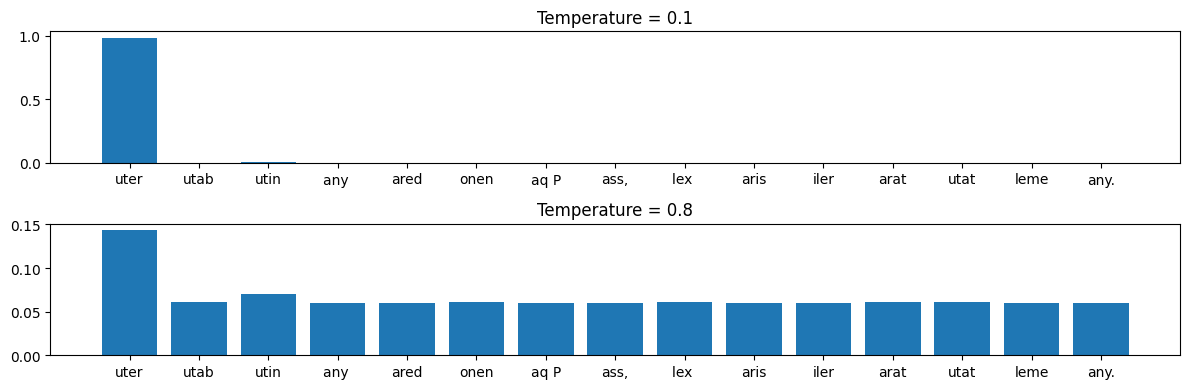

In [24]:
import math

def temperature_prob(probs, temperature=0.2):
    if temperature <= 0:
        raise ValueError("Temperature must be greater than 0.")

    scaled = [p / temperature for p in probs]

    # subtracting the max value to avoid overflow in the exponential function
    max_scaled = max(scaled)
    exp_vals = [ math.exp(x - max_scaled) for x in scaled ]

    total = sum(exp_vals)
    return [v / total for v in exp_vals]


fig, ax = plt.subplots(2, 1, figsize=(12, 4))
fig.tight_layout()

t_probs = temperature_prob(pb, temperature=0.1)
ax[0].bar(tk, t_probs)
ax[0].set_title('Temperature = 0.1')

t_probs = temperature_prob(pb, temperature=0.8)
ax[1].bar(tk, t_probs)
ax[1].set_title('Temperature = 0.8')
plt.tight_layout()
plt.show()

In this example, we can see that with a low temperature, the most probable token "uter" has almost 100% probability. When generating text with this temperature, we will get "Computer" almost all the time. This is useful if we want a deterministic generation that always generates the same text given the same input.

With a higher temperature, we can see that the probabilities of the less probable tokens increase, giving more chance to generate those tokens. This is useful if we want a diverse generation and variations of a text. For example, if we want to generate a poem, a high temperature is desired since it can generate more creative and diverse text.

In [25]:
def generate_t(markov, s, n_grams, wi, iw, max_tokens=100, t=0.2):
    ns = s
    if len(ns) % n_grams != 0:
        ns = ns[(len(ns) % n_grams):]

    tokens = tokenize(ns, n_grams, sliding=False)
    last_token = wi[tokens[-1]]
    for _ in range(max_tokens):
        probs = markov[last_token]
        full_probs = [probs[x] if x in probs else 0 for x in range(len(iw))]
        full_probs = temperature_prob(full_probs, temperature=t)
        sampled_token = random.choices(range(len(iw)), weights=full_probs, k=1)[0]
        last_token = sampled_token
        s += iw[sampled_token]
    return s

n_grams = 4

tokens = tokenize(cleaned_text, n_grams)
wi, iw = build_vocab(tokens)
markov = compute_markov(tokens, wi, n_grams, normalize=False)
s = 'Computer'

t1 = 0.2
generated_text = generate_t(markov, s, n_grams, wi, iw, max_tokens=100, t=t1)
print(f'Temperature = {t1}')
print(generated_text)

print('------')
t2 = 0.4
generated_text = generate_t(markov, s, n_grams, wi, iw, max_tokens=100, t=t2)
print(f'Temperature = {t2}')
print(generated_text)

Temperature = 0.2
Computer programming languages and applications that the original on 30 July 2019.
^ a b c d.268Lorel-Bīel" ve differential analog computer programming the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on 
------
Temperature = 0.4
Computer programming languages and aass,. Gems (. 20. H.) ush un978
blishing3, Resoumprey/Ju: Frty Em
Oumat
qualr fi supercomputers and the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on the original on 


---

The temperature sampling can break our model since it is very simple. But for better models like LLMs, it is a very useful technique to control the diversity of the generated text.

Also, other sampling techniques like top-k sampling and even a regex-restricted sampling can be used to control the generation and make it more useful for specific applications.

## Evaluation

One of the functions of a language model is to assign a probability to a given text. If this text is from the same distribution as the training data, it should have a high probability. So a good way to evaluate our model is to verify if it is assigning a high probability to the original text.

This probability is computed by multiplying the probabilities of each token given the previous token. As we don't have the true probability of a sequence start, and dealing with padding can make our examples more complex, we will simplify things here and approximate the probability of the sequence by the average of the product of probabilities of each token given the previous token.

Another thing is that by multiplying probabilities, we can get underflow problems since they are less than or equal to 1, and the result can be zero for every sequence. To avoid this, we can use the property called the product rule for logarithms, which says that the logarithm of a product is equal to the sum of logarithms. So instead of multiplying the probabilities, we can sum the logarithms of the probabilities and then take the exponential of the result to get the final probability. This way, we can avoid underflow problems.

In [26]:
def compute_prob(markov, s, n_grams, wi):
    # truncate the start of the sequence to simplify the example and avoid dealing with padding
    if len(s) % n_grams != 0:
        s = s[:-(len(s) % n_grams)]

    # tokenize the sequence
    tokens = tokenize(s, n_grams, sliding=False)
    previous = wi[tokens[0]]

    # starting with a probability of 1 (log(1) = 0)
    final_prob = 0
    for t in tokens[1:]:
        current = wi[t]
        probs = markov[previous]
        current_prob = probs[current]
        # adding the logarithm of the probability to avoid underflow
        final_prob += math.log(current_prob)
        previous = current

    # normalizing the probability by the length of the sequence to get an average probability per token
    return final_prob / len(tokens)

# a sample of the original text
s = cleaned_text[2003:2508]
n_grams = 4

tokens = tokenize(cleaned_text, n_grams)
wi, iw = build_vocab(tokens)
markov = compute_markov(tokens, wi, n_grams)

prob = compute_prob(markov, s, n_grams, wi)

print(prob)

-2.0589595714224735


With this approach, we can compare the probability the model is assigning to a text and verify which approach is assigning the higher probability. In this way, we can compare different models and see which one is better.

Another metric used to evaluate language models is the perplexity, which is defined as the inverse of the probability of the sequence normalized by the length of the sequence. The lower the perplexity, the better the model is at assigning high probability to the original text. The perplexity can be computed as:

In [27]:
def perplexity(markov, s, n_grams, wi):
    p = compute_prob(markov, s, n_grams, wi)
    return math.exp(-p / (len(s) / n_grams))

print(perplexity(markov, s, n_grams, wi))

1.0164423016196071


## Improving our model

The Markov model we built is very simple and has a lot of limitations. One of the main limitations is that it only considers the previous token to predict the next token. We can improve our model by considering the previous h tokens to predict the next token. By considering more tokens, we can capture more context and better model our sequences since we have different probabilities based on the previous history of tokens.

To implement this model, we need to change the way we build our matrix of probabilities. Instead of having a matrix where the rows are the current token and the columns are the next token, we will have a matrix where the rows are the history of h tokens, and the columns are the next token.

Also, since there is no history for the first token, we need to add a special token to represent the start of the sequence. To simplify this, we will just add spaces to the start of the text until we have enough tokens to fill the history. Another difference is that by using matrices, we need to create another word index that assigns an index to each possible history of tokens. Since we are using a dictionary to store the probabilities, we can simplify things to just use the whole history of tokens as the key in the dictionary. This works for CPU implementations, but for GPU implementations, the indexing is required.

In [28]:
def compute_markov_h(tokens, wi, n_grams, h=1, normalize=True):
    # still using a dictionary to store the probabilities
    # but now the keys are the history of tokens instead of the current token
    mat = {}

    for i in range(len(tokens)):
        current = tokens[i]

        # computing the history of tokens, skipping the intersection of the n-grams
        # as we are using the sliding window approach
        hist_h = [i - n_grams * j for j in range(h, 0,-1)]

        # mapping each token and if the position of the token is before the start of the sequence
        # We will use the spaces for padding
        hist_t = [wi[tokens[j]] if j >= 0 else wi[' ' * n_grams] for j in hist_h]

        # the keys are now the history
        ht = tuple(hist_t)
        if ht not in mat:
            mat[ht] = {}

        if wi[current] not in mat[ht]:
            mat[ht][wi[current]] = 0

        mat[ht][wi[current]] += 1

    if not normalize:
        return mat

    for ht in mat:
        total = sum(mat[ht].values())
        for next_token in mat[ht]:
            mat[ht][next_token] /= total

    return mat

The generation is computed similarly, but now we need to keep track of the history of tokens to get the next token. We also need to update the history after generating each token.

In [29]:
def generate_h(markov, s, n_grams, wi, iw, h=1, max_tokens=100):
    # truncating the start of the sequence to simplify
    ns = s
    if len(ns) % n_grams != 0:
        ns = ns[(len(ns) % n_grams):]


    tokens = tokenize(ns, n_grams, sliding=False)

    # the history is initialized with the last h tokens of the input sequence
    hist = [wi[x] for x in tokens[-h:]]

    for _ in range(max_tokens):
        # probabilities of the next tokens given the current history
        probs = markov[tuple(hist)]

        # adding the probabilities of all tokens in the vocabulary
        full_probs = [probs[x] if x in probs else 0 for x in range(len(iw))]

        # sampling as before
        sampled_token = random.choices(range(len(iw)), weights=full_probs, k=1)[0]
        s += iw[sampled_token]

        # updating the history by removing the oldest token and adding the new token at the end
        hist.pop(0)
        hist.append(sampled_token)

    return s

n_grams = 2
h = 6
tokens = tokenize(cleaned_text, n_grams)
wi, iw = build_vocab(tokens)
markov_h = compute_markov_h(tokens, wi, n_grams, h=h)


s = 'Computers are'

generated_text = generate_h(markov_h, s, n_grams, wi, iw, h=h, max_tokens=500)
print(generated_text)

Computers are said to be Turing-complete. Nine Mk II Colossi were built (The Mk I was converted to a Mk II making ten machines in some respects, pioneering numerous advances such as floating-point arithmetic problems that Kilby's had not. Produced at Fairchild Semiconductor Engineering. Springer Science & Business Media. p. 120. ISBN 978-3-540-34258-8.
^ Ligenza, J.R.; Spitzer, W.G. (July 1960). "The mechanism: computing after a dead moth was found shorting a relay in the Harvard architecture instructions (program) stored on tape, allowing the machine to be programmable gate array (FPGA)
Field-programmable object array (FPOA)
Applications
Audio equipment
Automotive electronics
Digital electronics
Multimedia
DirectX, OpenGL, OpenAL, Vulkan (API)
Programming languages by category, Generational list of programming languages, List of programmers years to write, and due to the computer's operating system computers, video editing, Image processing element, typically semiconductor material ..

A lot of improvement as the text now starts to make more sense, and it almost writes every word correctly. To test it, we also need to change the way we compute the probability of a sequence to consider the history of tokens.

Also, we need to consider the cases of OOV tokens and the cases where the history is not in the model. In those cases, we can assign a very low probability to those tokens to avoid getting zero probability for the whole sequence.

In [30]:
def compute_prob_h(markov, s, n_grams, wi, h=1):
    # truncate
    if len(s) % n_grams != 0:
        s = s[:-(len(s) % n_grams)]

    tokens = tokenize(s, n_grams, sliding=False)

    # if a token is not in the vocabulary, we can assign a random token from the vocabulary to it to avoid getting zero probability for the whole sequence
    hist = [wi[x] if x in wi else random.choice(list(wi.values())) for x in tokens[:h]]

    # starting with a probability of 1 (log(1) = 0)
    p = 0

    for token in tokens[h:]:
        # fallbacks for OOV tokens and history not in the model
        current_p = 1e-10
        current = wi[' ' * n_grams]
        probs = {}

        # if the token is in the vocabulary, we can get its index
        if token in wi:
            current = wi[token]

        # If the history is in the model, we can get the probabilities of the next tokens given the current history
        if tuple(hist) in markov:
            probs = markov[tuple(hist)]

        # if the current token is in the probabilities of the next tokens given the current history, we can get its probability
        if current in probs:
            current_p = math.log(probs[current])

        p += current_p

        # updating the history
        hist.pop(0)
        hist.append(current)

    # normalizing the probability by the length of the sequence
    return p / len(tokens)

# testing a sample of the original text
s = cleaned_text[2003:2508]
print(s)

prob = compute_prob_h(markov_h, s, n_grams, wi, h=h)
print(prob)

both electromechanical and using thermionic valves. The first semiconductor transistors in the late 1940s were followed by the silicon-based MOSFET (MOS transistor) and monolithic integrated circuit chip technologies in the late 1950s, leading to the microprocessor and the microcomputer revolution in the 1970s. The speed, power, and versatility of computers have been increasing dramatically ever since then, with transistor counts increasing at a rapid pace (Moore's law noted that counts doubled every
-0.14659208052754247


In [31]:
# We also have the perplexity for the history model

def perplexity_h(markov, s, n_grams, wi, h=1):
    p = compute_prob_h(markov, s, n_grams, wi, h=h)
    return math.exp(-p / (len(s) / n_grams))

print(perplexity_h(markov_h, s, n_grams, wi, h=h))

1.0005807312542983


Now let's compare the perplexity of both approaches as we increase the n-grams and the history size.

  0%|          | 0/14 [00:00<?, ?it/s]

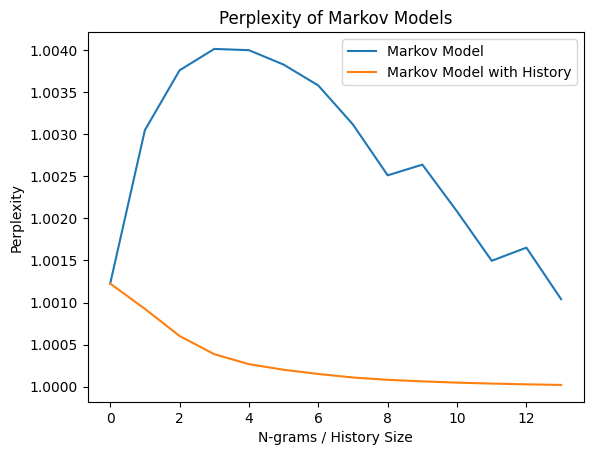

In [32]:
# a progress bar since this can take a while
from tqdm.auto import tqdm

# 2000 characters sample of the original text
s = cleaned_text[2000:4000]


p1 = []
p2 = []

# We will test n-grams from 1 to 15 and history size from 1 to 15 while predicting just the next character in the history model
for n in tqdm(range(1, 15)):
    tokens = tokenize(cleaned_text, n)
    wi, iw = build_vocab(tokens)

    markov1 = compute_markov(tokens, wi, n)
    p1.append(perplexity(markov1, s, n, wi))

    tokens = tokenize(cleaned_text, 1)
    wi, iw = build_vocab(tokens)
    markov2 = compute_markov_h(tokens, wi, 1, h=n)
    p2.append(perplexity_h(markov2, s, 1, wi, h=n))


plt.title('Perplexity of Markov Models')
plt.plot(p1, label='Markov Model')
plt.plot(p2, label='Markov Model with History')
plt.xlabel('N-grams / History Size')
plt.ylabel('Perplexity')
plt.legend()
plt.show()

The perplexity of the Markov model with and without history starts increasing as we increase the n-grams, and then starts decreasing after a certain point. A similar behaviour from the number of tokens and the vocabulary size we saw before. The perplexity of the Markov model decreases and is already lower than the Markov model without history, with just a history size of 2, showing that the number of context tokens is more important than the n-gram size to model.

Another interesting thing to see is that both perplexities approach as we increase the n-grams and the history size. With the maximum n being the length of the text, we have only one token, which is the whole text, so both models will assign 100% probability to the original text.

## Applications

We saw how to build a language model using Markov chains and how to use it to generate text and evaluate it. Now let's see some applications of this model. The applications are endless, but we will see an example using the model capacity of assigning a high probability to a text from the same distribution as the training data and a lower probability to anything else.

Suppose we have a dataset of code and we train a language model on it. Given a sample of different code but in the same programming language, if the model was correctly trained, it should assign a higher probability to it and a lower probability to any other language. This can be used to create a programming language detector or a file type detector. Or you can train a spam language model and use it to detect if an email is spam or not.

To see this working, let's try a programming language detector. For this, we will get some large files in C++ and some code snippets in different programming languages and see if the model can assign a higher probability to the C++ code than to the other languages.


In [33]:
# some files in c++ to train our model
train = [
    'https://raw.githubusercontent.com/opentibiabr/otclient/refs/heads/main/src/client/game.cpp',
    'https://raw.githubusercontent.com/opentibiabr/otclient/refs/heads/main/src/framework/ui/uiwidget.cpp',
    'https://raw.githubusercontent.com/opentibiabr/otclient/refs/heads/main/src/client/creature.cpp'
]

train_texts = []
for url in train:
    response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
    train_texts.append(response.text)

In [34]:
# a sample of c++ code
test1 = ''''#include "player.h"

bool Player::isMage() const {
    switch (m_vocation) {
        case Otc::Vocations_t::SORCERER:
        case Otc::Vocations_t::DRUID:
        case Otc::Vocations_t::MASTER_SORCERER:
        case Otc::Vocations_t::ELDER_DRUID:
            return true;
        default: return false;
    }
}'''

# a sample of xml
test2 = '''<?xml version="1.0"?>
<catalog>
   <book id="bk101">
      <author>Gambardella, Matthew</author>
      <title>XML Developer's Guide</title>
      <genre>Computer</genre>
      <price>44.95</price>
      <publish_date>2000-10-01</publish_date>
      <description>An in-depth look at creating applications
      with XML.</description>
   </book>'''

# a sample of Python from this tutorial
test3 = '''def generate(markov, s, n_grams, wi, iw, max_tokens=100):
    ns = s
    if len(ns) % n_grams != 0:
        ns = ns[(len(ns) % n_grams):]

    tokens = tokenize(ns, n_grams, sliding=False)
    last_token = wi[tokens[-1]]
    for _ in range(max_tokens):
        probs = markov[last_token]
        full_probs = [probs[x] if x in probs else 0 for x in range(len(iw))]
        sampled_token = random.choices(range(len(iw)), weights=full_probs, k=1)[0]
        last_token = sampled_token
        s += iw[sampled_token]
    return s'''


tests = [test1, test2, test3]
test_tags = ['cpp', 'xml', 'python']

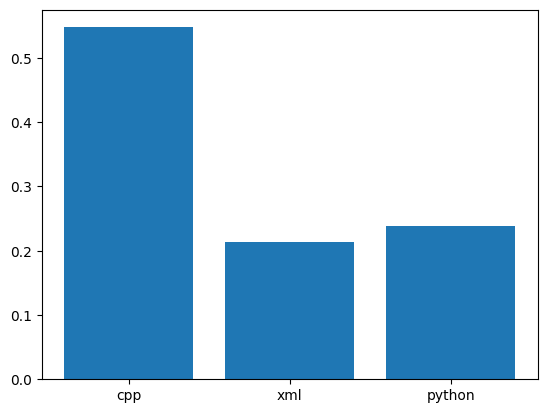

In [35]:
n_grams = 2
h = 4
tokens = tokenize('\n'.join(train_texts), n_grams)
wi, iw = build_vocab(tokens)
markov_h = compute_markov_h(tokens, wi, n_grams, h=h, normalize=False)

probabilities = [compute_prob_h(markov_h, x, n_grams, wi, h=h) for x in tests]

exp = [math.exp(x) for x in probabilities]
total = sum(exp)
probs = [x / total for x in exp]

plt.bar(test_tags, probs)
plt.show()

And it works. We can see that the model assigns a higher probability to C++ code than to the other languages.

We have some problems with this approach. For example, if we want to train a programming language classifier, we need to train one language model for each language and then compare the probabilities of the test code in each model to see which one is higher. This can be very inefficient if we have a lot of languages to classify. Also, if we want to classify a text that is not in the training data, it will be hard to assign a probability to it since it will have a lot of OOV tokens.

Another problem is that we can't model long-range dependencies with this approach since we are only considering the previous h tokens to predict the next token. This is especially problematic for programming languages. One example is that module imports may appear at the start of the code, and then the imported module is used at the end of the code, leading to a long-range dependency that our model can't capture. Increasing the history size won't help in this approach, and to continue improving, we need a better approach.



## Next steps

The Markov model we built is a very simple model and has a lot of limitations. To continue improving, we need to use a better approach that can capture long-range dependencies and model more complex patterns in the text. Inspired by the human brain, we can use a neural network to improve the language modelling capabilities of our approach.

In the next chapters, we will see how deep learning can help us build architectures that improve the capabilities of our language model and other tasks.